In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cambia la ruta por donde tengas guardado tu archivo
df = pd.read_csv('data.csv', encoding='latin1')

# Ver las primeras filas
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [3]:
print("Forma del dataset:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:\n", df.dtypes)
print("\nValores nulos:\n", df.isnull().sum())

Forma del dataset: (541909, 8)

Columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Tipos de datos:
 InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Valores nulos:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
# Eliminamos filas sin descripción
df = df.dropna(subset=['Description'])

# Eliminamos transacciones con cantidad 0 o negativa (devoluciones)
df = df[df['Quantity'] > 0]

# Eliminamos transacciones con precio 0 o negativo
df = df[df['UnitPrice'] > 0]

# Convertimos la fecha a formato datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Filas después de limpiar:", df.shape[0])
print("Valores nulos restantes:\n", df.isnull().sum())

Filas después de limpiar: 530104
Valores nulos restantes:
 InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64


In [6]:
# Creamos columna de ventas (cantidad x precio)
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Agrupamos por día
df_daily = df.groupby(df['InvoiceDate'].dt.date)['TotalSales'].sum().reset_index()
df_daily.columns = ['Date', 'TotalSales']
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

# Ordenamos por fecha
df_daily = df_daily.sort_values('Date').reset_index(drop=True)

print("Días totales en el dataset:", len(df_daily))
df_daily.head(10)

Días totales en el dataset: 305


,Date,TotalSales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46
5,2010-12-07,99618.20
6,2010-12-08,45389.98
7,2010-12-09,53586.18
8,2010-12-10,59182.92
9,2010-12-12,17329.07


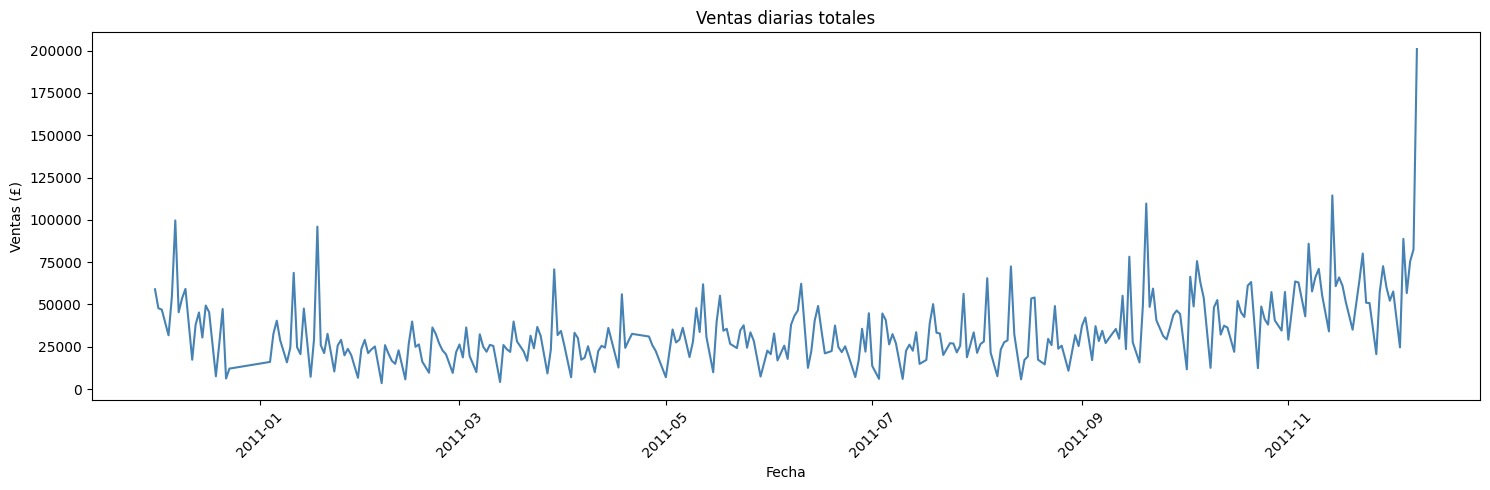

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(df_daily['Date'], df_daily['TotalSales'], color='steelblue')
plt.title('Ventas diarias totales')
plt.xlabel('Fecha')
plt.ylabel('Ventas (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Fechas de corte
train_end = '2011-10-08'
val_end = '2011-11-08'

# División
train = df_daily[df_daily['Date'] <= train_end]
val = df_daily[(df_daily['Date'] > train_end) & (df_daily['Date'] <= val_end)]
test = df_daily[df_daily['Date'] > val_end]

print("Días en entrenamiento:", len(train))
print("Días en validación:", len(val))
print("Días en test:", len(test))

Días en entrenamiento: 251
Días en validación: 27
Días en test: 27


In [10]:
# Normalizamos las ventas entre 0 y 1
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['TotalSales']])
val_scaled = scaler.transform(val[['TotalSales']])
test_scaled = scaler.transform(test[['TotalSales']])

print("Datos normalizados correctamente")
print("Ejemplo de valores normalizados:", train_scaled[:5].flatten())

Datos normalizados correctamente
Ejemplo de valores normalizados: [0.52285546 0.41723238 0.40965223 0.26675956 0.48394695]


In [12]:
# Esta función convierte la serie en secuencias de X días
def crear_secuencias(data, ventana=7):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana])
    return np.array(X), np.array(y)

# Usamos una ventana de 7 días
VENTANA = 7

X_train, y_train = crear_secuencias(train_scaled, VENTANA)
X_val, y_val = crear_secuencias(val_scaled, VENTANA)
X_test, y_test = crear_secuencias(test_scaled, VENTANA)

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)

Forma de X_train: (244, 7, 1)
Forma de y_train: (244, 1)
Forma de X_test: (20, 7, 1)


In [14]:
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Construimos el modelo
model = Sequential([
    LSTM(64, activation='relu', input_shape=(VENTANA, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

ImportError: DLL load failed while importing _pywrap_tensorflow_lite_metrics_wrapper: No se encontró el proceso especificado.

In [ ]:
# Early stopping para evitar overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenamos
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("✅ Entrenamiento completado")